In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import itertools

from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
class Fuzzy:
    class Trimf:
        def __init__(self, universe, abc):
            self.universe = universe
            self.abc = abc
            self.values = Fuzzy.Trimf.evaluateTrimfArray(universe, abc)

        @staticmethod
        def trimf(universe, abc):
            return Fuzzy.Trimf(universe, abc)

        @staticmethod
        def evaluateTrimfArray(universe, abc):
            a, b, c = abc
            values = np.zeros_like(universe, dtype=float)
            for i, x in enumerate(universe):
                if a < x < b:
                    values[i] = (x - a) / (b - a) if b != a else 1.0
                elif b <= x < c:
                    values[i] = (c - x) / (c - b) if c != b else 1.0
                elif x == b:
                    values[i] = 1.0
            return values

        @staticmethod
        def evaluateMfScalar(mf, x):
            if isinstance(mf, Fuzzy.Trimf):
                a, b, c = mf.abc
                if x < a or x > c:
                    return 0.0
                if a <= x <= b:
                    if b == a:
                        return 1.0 if x == a else 0.0
                    return (x - a) / (b - a) if b != a else 0.0
                if b < x <= c:
                    if b == c:
                        return 1.0 if x == c else 0.0
                    return (c - x) / (c - b) if c != b else 0.0
                if x == b:
                    return 1.0
            return 0.0

    class FuzzyTerm:
        def __init__(self, variable, label):
            self.variable = variable
            self.label = label

        def __and__(self, other):
            return Fuzzy.RuleCondition(self, other, "AND")

        def __or__(self, other):
            return Fuzzy.RuleCondition(self, other, "OR")

    class RuleCondition:
        def __init__(self, left, right, operator):
            self.left = left
            self.right = right
            self.operator = operator

        def __and__(self, other):
            return Fuzzy.RuleCondition(self, other, "AND")

        def __or__(self, other):
            return Fuzzy.RuleCondition(self, other, "OR")

    @staticmethod
    def evaluateCondition(condition, inputs):
        if isinstance(condition, Fuzzy.FuzzyTerm):
            varName = condition.variable.name
            label = condition.label
            x = inputs.get(varName, 0.0)
            mf = condition.variable.terms[label]
            return Fuzzy.Trimf.evaluateMfScalar(mf, x)
        elif isinstance(condition, Fuzzy.RuleCondition):
            leftVal = Fuzzy.evaluateCondition(condition.left, inputs)
            rightVal = Fuzzy.evaluateCondition(condition.right, inputs)
            if condition.operator == "AND":
                return min(leftVal, rightVal)
            elif condition.operator == "OR":
                return max(leftVal, rightVal)
        return 0.0

    class Antecedent:
        def __init__(self, universe, name):
            self.universe = universe
            self.name = name
            self.terms = {}

        def __setitem__(self, label, mf):
            self.terms[label] = mf

        def __getitem__(self, label):
            return Fuzzy.FuzzyTerm(self, label)

    class Consequent:
        def __init__(self, universe, name):
            self.universe = universe
            self.name = name
            self.terms = {}

        def __setitem__(self, label, mf):
            self.terms[label] = mf

        def __getitem__(self, label):
            return Fuzzy.FuzzyTerm(self, label)

    class Rule:
        def __init__(self, antecedentCondition, consequentTerm):
            self.antecedentCondition = antecedentCondition
            self.consequentTerm = consequentTerm

    class ControlSystem:
        def __init__(self, rules=None):
            self.rules = rules if rules is not None else []

    class ControlSystemSimulation:
        def __init__(self, controlSystem):
            self.controlSystem = controlSystem
            self.input = {}
            self.output = {}

        def compute(self):
            consequentOutputs = {}
            for rule in self.controlSystem.rules:
                firingStrength = Fuzzy.evaluateCondition(
                    rule.antecedentCondition, self.input
                )
                consequentVar = rule.consequentTerm.variable
                consequentLabel = rule.consequentTerm.label
                mf = consequentVar.terms[consequentLabel]

                clippedValues = np.minimum(firingStrength, mf.values)
                if consequentVar.name not in consequentOutputs:
                    consequentOutputs[consequentVar.name] = np.zeros_like(
                        consequentVar.universe, dtype=float
                    )
                consequentOutputs[consequentVar.name] = np.maximum(
                    consequentOutputs[consequentVar.name], clippedValues
                )

            for varName, aggregatedMf in consequentOutputs.items():
                consequentVar = None
                for rule in self.controlSystem.rules:
                    if rule.consequentTerm.variable.name == varName:
                        consequentVar = rule.consequentTerm.variable
                        break
                sumMf = np.sum(aggregatedMf)
                if sumMf == 0:
                    self.output[varName] = np.mean(consequentVar.universe)
                else:
                    self.output[varName] = (
                        np.sum(consequentVar.universe * aggregatedMf) / sumMf
                    )

In [3]:
def generateGridPartitioningRules(antecedents, consequent):
    rules = []
    termLists = [(ant, list(ant.terms.keys())) for ant in antecedents]
    combinations = list(itertools.product(*[t[1] for t in termLists]))
    consequentTerms = list(consequent.terms.keys())
    numCons = len(consequentTerms)

    for combo in combinations:
        cond = antecedents[0][combo[0]]
        score = termLists[0][1].index(combo[0])

        for j in range(1, len(antecedents)):
            cond = cond & antecedents[j][combo[j]]
            score += termLists[j][1].index(combo[j])

        maxScore = sum([len(t[1]) - 1 for t in termLists])
        normalizedScore = score / maxScore if maxScore > 0 else 0
        consIndex = int(round(normalizedScore * (numCons - 1)))

        consTerm = consequentTerms[consIndex]
        rules.append(Fuzzy.Rule(cond, consequent[consTerm]))

    return rules

In [4]:
def getUniqueVariables(system):
    antecedents = {}
    consequents = {}

    def collectVariables(condition):
        if isinstance(condition, Fuzzy.FuzzyTerm):
            antecedents[condition.variable.name] = condition.variable
        elif isinstance(condition, Fuzzy.RuleCondition):
            collectVariables(condition.left)
            collectVariables(condition.right)

    for rule in system.rules:
        collectVariables(rule.antecedentCondition)
        consequents[rule.consequentTerm.variable.name] = rule.consequentTerm.variable

    return list(antecedents.values()), list(consequents.values())

In [5]:
def applyParametersToSystem(system, parameterVector):
    antecedents, consequents = getUniqueVariables(system)
    idx = 0
    for var in antecedents + consequents:
        for label in var.terms.keys():
            abc = sorted(parameterVector[idx : idx + 3])
            var.terms[label] = Fuzzy.Trimf.trimf(var.universe, abc)
            idx += 3
    return system

In [6]:
def pythonGenfis(trainX, trainY, numMfs=3):
    numFeatures = trainX.shape[1]
    antecedents = []

    for i in range(numFeatures):
        featMin = trainX[:, i].min()
        featMax = trainX[:, i].max()
        if featMin == featMax:
            featMax += 1.0
        universe = np.linspace(featMin, featMax, 100)
        ant = ctrl.Antecedent(universe, f"input{i}")

        centers = np.linspace(featMin, featMax, numMfs)
        for j in range(numMfs):
            if j == 0:
                abc = [featMin, featMin, centers[j + 1] if numMfs > 1 else featMax]
            elif j == numMfs - 1:
                abc = [centers[j - 1], featMax, featMax]
            else:
                abc = [centers[j - 1], centers[j], centers[j + 1]]
            ant[f"mf{j}"] = fuzz.trimf(ant.universe, abc)
        antecedents.append(ant)

    outMin = trainY.min()
    outMax = trainY.max()
    if outMin == outMax:
        outMax += 1.0
    outUniverse = np.linspace(outMin, outMax, 100)
    consequent = ctrl.Consequent(outUniverse, "output")
    outCenters = np.linspace(outMin, outMax, numMfs)

    for j in range(numMfs):
        if j == 0:
            abc = [outMin, outMin, outCenters[j + 1] if numMfs > 1 else outMax]
        elif j == numMfs - 1:
            abc = [outCenters[j - 1], outMax, outMax]
        else:
            abc = [outCenters[j - 1], outCenters[j], outCenters[j + 1]]
        consequent[f"mf{j}"] = fuzz.trimf(consequent.universe, abc)

    rules = []
    seenRules = set()

    for i in range(len(trainX)):
        bestAntLabels = []
        for j, ant in enumerate(antecedents):
            bestLabel = None
            maxMu = -1.0
            for label in ant.terms.keys():
                mu = fuzz.interp_membership(ant.universe, ant[label].mf, trainX[i, j])
                if mu > maxMu:
                    maxMu = mu
                    bestLabel = label
            bestAntLabels.append(bestLabel)

        bestOutLabel = None
        maxMuOut = -1.0
        for label in consequent.terms.keys():
            mu = fuzz.interp_membership(consequent.universe, consequent[label].mf, trainY[i])
            if mu > maxMuOut:
                maxMuOut = mu
                bestOutLabel = label

        ruleKey = tuple(bestAntLabels)
        if ruleKey not in seenRules and bestOutLabel is not None:
            seenRules.add(ruleKey)
            cond = antecedents[0][bestAntLabels[0]]
            for k in range(1, len(antecedents)):
                cond = cond & antecedents[k][bestAntLabels[k]]
            rules.append(ctrl.Rule(cond, consequent[bestOutLabel]))

    if not rules:
        rules.append(ctrl.Rule(antecedents[0]["mf0"], consequent["mf0"]))

    system = ctrl.ControlSystem(rules)
    return ctrl.ControlSystemSimulation(system)

In [7]:
def loadSolarFlareData():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/solar-flare/flare.data2"
    try:
        df = pd.read_csv(url, sep=" ", skiprows=1, header=None)
        for col in [0, 1, 2]:
            df[col] = df[col].astype("category").cat.codes
        data = df.values.astype(float)
        X = data[:, :10]
        y = data[:, 10]
        return X, y
    except Exception:
        np.random.seed(42)
        X = np.random.randint(1, 4, size=(200, 10)).astype(float)
        y = np.random.randint(0, 5, size=(200,)).astype(float)
        return X, y

In [8]:
def evaluateCustomSystem(simulation, XData):
    predictions = []
    for i in range(len(XData)):
        simulation.input["evolution"] = XData[i, 4]
        simulation.input["prevActivity"] = XData[i, 5]
        simulation.compute()
        predictions.append(simulation.output.get("cClassFlares", 0.0))
    return np.array(predictions)

def evaluateSkfuzzySystem(simulation, XData):
    predictions = []
    for i in range(len(XData)):
        for j in range(XData.shape[1]):
            simulation.input[f"input{j}"] = XData[i, j]
        try:
            simulation.compute()
            predictions.append(simulation.output["output"])
        except Exception:
            predictions.append(0.0)
    return np.array(predictions)

In [9]:
def calculateMse(yTrue, yPred):
    return np.mean((yTrue - yPred) ** 2)

In [10]:
from SwarmAlgorithm import swarm_algorithm

def antColonyOptimization(trainX, trainY, baseSystem):
    print("Uruchamianie algorytmu roju (to może potrwać)...")
    
    best_params = swarm_algorithm(baseSystem, trainX, trainY)
    
    optimizedSystem = applyParametersToSystem(baseSystem, best_params)
    
    return optimizedSystem

In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_custom_mf(antecedent_or_consequent, title, filename):
    plt.figure(figsize=(6, 3))
    for label, mf in antecedent_or_consequent.terms.items():
        plt.plot(antecedent_or_consequent.universe, mf.values, label=label, linewidth=2)
    plt.title(f"Funkcje przynależności dla: {title}")
    plt.xlabel("Wartość")
    plt.ylabel("Stopień przynależności (\u03BC)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

def plot_decision_surface(simulation, title, filename):
    evo_vals = np.linspace(1, 3, 100)
    act_vals = np.linspace(1, 3, 100)
    evo_grid, act_grid = np.meshgrid(evo_vals, act_vals)
    
    test_points = np.transpose(np.vstack((np.ravel(evo_grid), np.ravel(act_grid))))
    
    z_values = []
    for i in range(len(test_points)):
        simulation.input["evolution"] = test_points[i, 0]
        simulation.input["prevActivity"] = test_points[i, 1]
        simulation.compute()
        z_values.append(simulation.output.get("cClassFlares", 0.0))
        
    z_grid = np.array(z_values).reshape(evo_grid.shape)
    
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(evo_grid, act_grid, z_grid, levels=50, cmap='coolwarm')
    plt.colorbar(contour, label='Liczba rozbłysków')
    
    plt.title(title)
    plt.xlabel('evolution')
    plt.ylabel('prevActivity')
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

MSE PRZED optymalizacją GOA: 5.2253


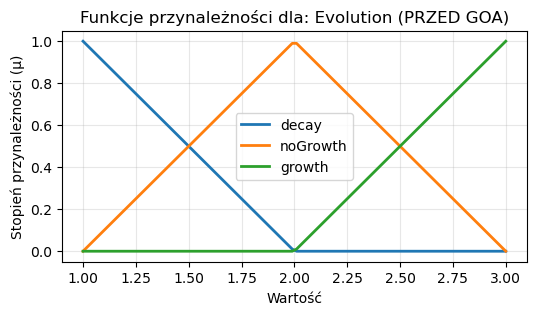

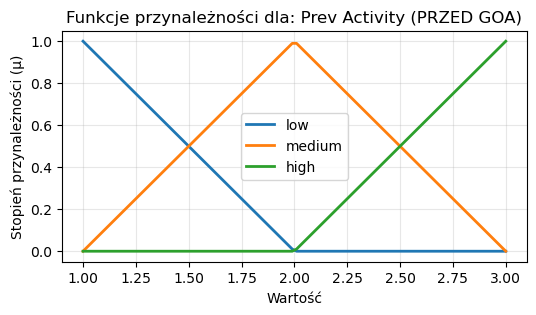

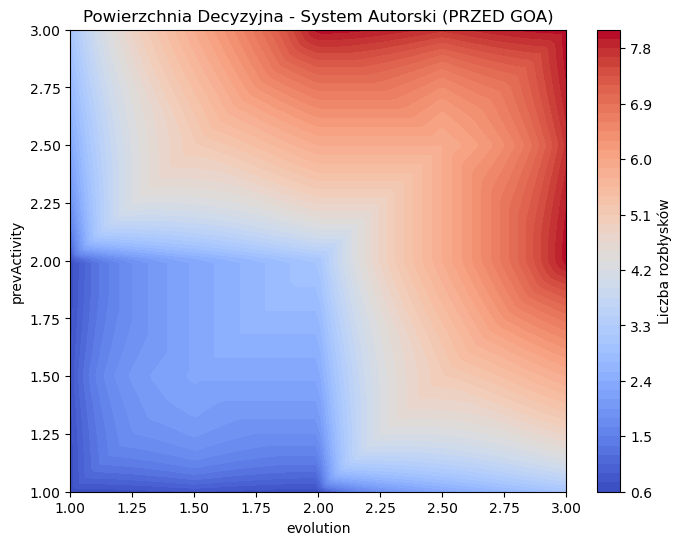

In [12]:
# 1. Ładowanie i podział danych
X, y = loadSolarFlareData()
halfIndex = len(X) // 2
trainX, testX = X[:halfIndex], X[halfIndex:]
trainY, testY = y[:halfIndex], y[halfIndex:]

evolutionUniverse = np.linspace(1, 3, 100)
prevActivityUniverse = np.linspace(1, 3, 100)
flaresUniverse = np.linspace(0, 10, 100)

evolution = Fuzzy.Antecedent(evolutionUniverse, "evolution")
prevActivity = Fuzzy.Antecedent(prevActivityUniverse, "prevActivity")
cClassFlares = Fuzzy.Consequent(flaresUniverse, "cClassFlares")

# 2. Ustawienia fabryczne trójkątów (PRZED ACO)
evolution["decay"] = Fuzzy.Trimf.trimf(evolutionUniverse, [1, 1, 2])
evolution["noGrowth"] = Fuzzy.Trimf.trimf(evolutionUniverse, [1, 2, 3])
evolution["growth"] = Fuzzy.Trimf.trimf(evolutionUniverse, [2, 3, 3])

prevActivity["low"] = Fuzzy.Trimf.trimf(prevActivityUniverse, [1, 1, 2])
prevActivity["medium"] = Fuzzy.Trimf.trimf(prevActivityUniverse, [1, 2, 3])
prevActivity["high"] = Fuzzy.Trimf.trimf(prevActivityUniverse, [2, 3, 3])

cClassFlares["none"] = Fuzzy.Trimf.trimf(flaresUniverse, [0, 0, 2])
cClassFlares["few"] = Fuzzy.Trimf.trimf(flaresUniverse, [1, 3, 5])
cClassFlares["many"] = Fuzzy.Trimf.trimf(flaresUniverse, [4, 10, 10])

# 3. Inicjalizacja i ewaluacja systemu
gridRules = generateGridPartitioningRules([evolution, prevActivity], cClassFlares)
customSystem = Fuzzy.ControlSystem(gridRules)
customSimulation = Fuzzy.ControlSystemSimulation(customSystem)

customPreds = evaluateCustomSystem(customSimulation, testX)
customMse = calculateMse(testY, customPreds)

print(f"MSE PRZED optymalizacją GOA: {customMse:.4f}")

# 4. Rysowanie stanu PRZED GOA
plot_custom_mf(evolution, "Evolution (PRZED GOA)", "evo_preGOA.pdf")
plot_custom_mf(prevActivity, "Prev Activity (PRZED GOA)", "PrevActiv_preGOA.pdf")
plot_decision_surface(customSimulation, "Powierzchnia Decyzyjna - System Autorski (PRZED GOA)", "heatmap_preGOA.pdf")

In [13]:
print("Rozpoczynam optymalizację rojem (GOA)...")
# Ta funkcja nadpisze parametry wejściowe zdefiniowane wyżej
tunedSystem = antColonyOptimization(trainX, trainY, customSystem)
print("Optymalizacja zakończona!")

Rozpoczynam optymalizację rojem (GOA)...
Uruchamianie algorytmu roju (to może potrwać)...
Epoch 0   Current best position: [2.39769618 2.60230137 1.13944561], with score: 3757.0634
Epoch 1   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 2   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 3   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 4   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 5   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 6   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 7   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 8   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 9   Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 10  Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 11  Current best position: [2.8 2.8 1. ], with score: 3619.8648
Epoch 12  Current best position: [2.8 2.8 1. ], w

MSE PO optymalizacji GOA: 6.4413
Różnica błędu: -1.2160


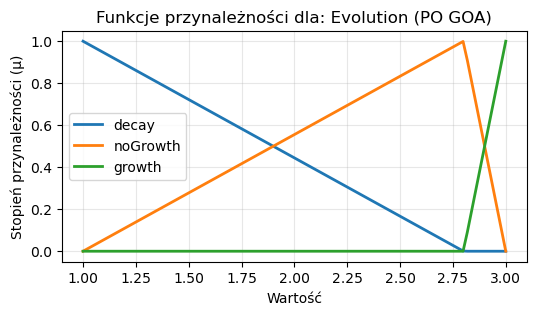

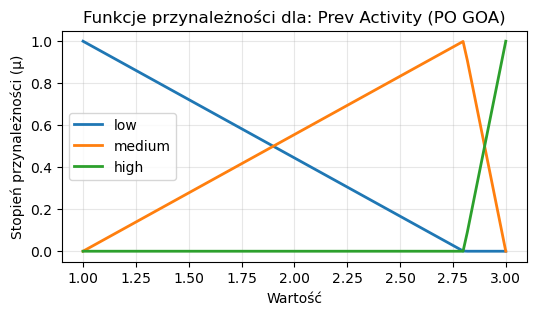

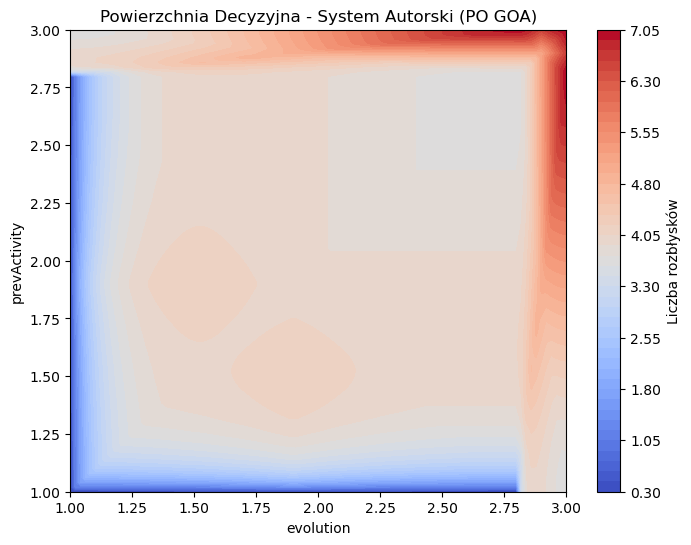

In [14]:
# 1. Ewaluacja systemu ze zaktualizowanymi parametrami
customSimulationACO = Fuzzy.ControlSystemSimulation(tunedSystem)
customPredsACO = evaluateCustomSystem(customSimulationACO, testX)
customMseACO = calculateMse(testY, customPredsACO)

print(f"MSE PO optymalizacji GOA: {customMseACO:.4f}")
print(f"Różnica błędu: {customMse - customMseACO:.4f}")

# 2. Rysowanie stanu PO GOA
plot_custom_mf(evolution, "Evolution (PO GOA)", "evo_postGOA.pdf")
plot_custom_mf(prevActivity, "Prev Activity (PO GOA)", "PrevActiv_postGOA.pdf")
plot_decision_surface(customSimulationACO, "Powierzchnia Decyzyjna - System Autorski (PO GOA)", "heatmap_postGOA.pdf")

In [15]:
# Skfuzzy z 10 zmiennymi wejściowymi
genfisSimulation = pythonGenfis(trainX, trainY, numMfs=3)
genfisPreds = evaluateSkfuzzySystem(genfisSimulation, testX)
genfisMse = calculateMse(testY, genfisPreds)

print(f"MSE Skfuzzy (Baseline 10 zmiennych): {genfisMse:.4f}")

# Ostateczne zestawienie
print("\n--- PODSUMOWANIE METRYK (ZBIÓR TESTOWY) ---")
print(f"MSE Przed GOA: {customMse:.4f} | R2: {r2_score(testY, customPreds):.4f} | MAE: {mean_absolute_error(testY, customPreds):.4f}")
print(f"MSE Po GOA:    {customMseACO:.4f} | R2: {r2_score(testY, customPredsACO):.4f} | MAE: {mean_absolute_error(testY, customPredsACO):.4f}")
print(f"MSE Skfuzzy:   {genfisMse:.4f} | R2: {r2_score(testY, genfisPreds):.4f} | MAE: {mean_absolute_error(testY, genfisPreds):.4f}")

MSE Skfuzzy (Baseline 10 zmiennych): 3.7645

--- PODSUMOWANIE METRYK (ZBIÓR TESTOWY) ---
MSE Przed GOA: 5.2253 | R2: -10.4042 | MAE: 1.7747
MSE Po GOA:    6.4413 | R2: -13.0582 | MAE: 1.9242
MSE Skfuzzy:   3.7645 | R2: -7.2161 | MAE: 1.7401
